# CardioIA — Fase 2 · Parte 2: classificador de risco com TF-IDF

> ⚠️ **AVISO CLÍNICO:** Este sistema é um protótipo acadêmico e **NÃO** substitui avaliação médica.  
> Supervisionado por Dra. Fernanda Fassina (CRM-SP 169944).

**Objetivo.** Classificar frases curtas de sintomas como **`alto risco`** ou **`baixo risco`**, simulando a priorização de uma triagem clínica.

**Como avaliamos** (detalhes no SDD, `.spec/SDD-fase2-nlp-triagem.md` §4–§5):

1. **Dataset** `data/frases_risco.csv`: 320 frases rotuladas por critério clínico explícito. O teste tem 60 frases escritas à mão e foi **congelado antes da primeira avaliação**.
2. **TF-IDF** (unigramas + bigramas), com a mesma normalização da Parte 1: sem acento e em minúsculas.
3. **Três modelos** do scikit-learn: Regressão Logística, Árvore de Decisão e Naive Bayes.
4. **Escolha do modelo só pela validação cruzada no treino.** O teste não participa da escolha.
5. **Uma avaliação** no teste congelado, contra as metas: recall de alto risco ≥ 0,90 e acurácia ≥ 0,80.

> **Por que recall?** Na triagem, o erro caro é o **falso negativo**: um paciente grave classificado como baixo risco vai para o fim da fila.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def achar_pasta_fase2():
    """Localiza fase2/ a partir de onde o notebook está sendo executado."""
    for pasta in [Path.cwd(), *Path.cwd().parents]:
        for candidata in (pasta, pasta / "fase2"):
            if (candidata / "src" / "extrator_sintomas.py").exists():
                return candidata
    raise FileNotFoundError("pasta fase2/ não encontrada")


FASE2 = achar_pasta_fase2()
sys.path.insert(0, str(FASE2 / "src"))

from avaliacao import NEGATIVO, POSITIVO, calcular_metricas, criar_modelos, executar
from carregador_base import carregar_base_conhecimento
from classificador_regras import classificar_por_regras
from contrato_dataset import carregar_dataset_risco, validar_dataset_risco

pd.set_option("display.max_colwidth", 110)
base = carregar_base_conhecimento()

## 1. O dataset

Cada frase tem o rótulo exigido pelo enunciado (`frase,situacao`) e três colunas de governança:

- **`origem`**: `manual` (escrita à mão, uma a uma) ou `template` (gerada a partir da base de conhecimento da Parte 1);
- **`particao`**: `treino` ou `teste`. Ela é fixa no arquivo, não sorteada aqui, e o teste só tem frases manuais;
- **`criterio`**: a regra clínica que justifica o rótulo (A1–A4 para alto risco, B1–B3 para baixo risco).

A linhagem completa (autoria, contagens e limitações) está em `data/frases_risco_LINHAGEM.md`.

In [2]:
df = carregar_dataset_risco()
print("Violações do contrato:", validar_dataset_risco(df) or "nenhuma")
df.sample(8, random_state=42)

Violações do contrato: nenhuma


,frase,situacao,origem,particao,criterio
167,Agora estou com aperto forte no peito e fiquei tonta.,alto risco,template,treino,A1
230,Fico um pouco cansada quando carrego peso há anos.,baixo risco,template,treino,B1
25,Fiquei muito tonto e perdi a consciência por um instante enquanto subia a escada.,alto risco,manual,teste,A2
63,Faz quase uma hora que estou com desconforto no peito que não alivia de jeito nenhum.,alto risco,manual,treino,A1
9,Minha angina mudou: agora a dor aparece até quando estou parado e dura mais.,alto risco,manual,teste,A1
110,Estou meio sem energia nesta semana por causa das provas da faculdade.,baixo risco,manual,treino,B1
186,Do nada perdi a consciência no meio da aula.,alto risco,template,treino,A2
143,Senti peso no peito que começou de repente.,alto risco,template,treino,A1


In [3]:
pd.crosstab([df["particao"], df["origem"]], df["situacao"], margins=True, margins_name="total")

situacao           alto risco  baixo risco  total
particao origem                                  
teste    manual            30           30     60
treino   manual            40           40     80
         template          90           90    180
total                     160          160    320

In [4]:
criterios = {
    "A1": "dor torácica + sinal de alarme", "A2": "síncope", "A3": "dispneia em repouso/súbita/noturna",
    "A4": "equivalente atípico", "B1": "sintoma leve e estável", "B2": "queixa não cardíaca", "B3": "alarme negado",
}
tabela = pd.crosstab(df["criterio"], df["particao"])
tabela.insert(0, "significado", tabela.index.map(criterios))
tabela

particao,significado,teste,treino
criterio,,,
A1,dor torácica + sinal de alarme,17,63
A2,síncope,4,22
A3,dispneia em repouso/súbita/noturna,5,22
A4,equivalente atípico,4,23
B1,sintoma leve e estável,13,51
B2,queixa não cardíaca,13,51
B3,alarme negado,4,28


## 2. TF-IDF: transformando frases em números

O TF-IDF dá a cada palavra (e par de palavras) um peso que cresce com a frequência dela na frase e diminui quando ela aparece em muitas frases. Palavras raras e específicas pesam mais que palavras comuns. O vetorizador usa a mesma normalização da Parte 1, então "pressão" e "pressao" viram o mesmo termo.

In [5]:
treino = df[df["particao"] == "treino"]
teste = df[df["particao"] == "teste"]

vetorizador = criar_modelos()["logreg"].named_steps["tfidf"].fit(treino["frase"])
print(f"Vocabulário aprendido no treino: {len(vetorizador.vocabulary_)} termos (unigramas + bigramas)")

for frase in ["Sinto dor no peito e falta de ar", "Tive um leve incômodo nas costas"]:
    vetor = vetorizador.transform([frase]).toarray()[0]
    termos = np.array(vetorizador.get_feature_names_out())
    pesos = pd.Series(vetor, index=termos)
    print(f"\n{frase!r} → {(vetor > 0).sum()} termos com peso")
    print(pesos[pesos > 0].sort_values(ascending=False).round(3).to_string())

Vocabulário aprendido no treino: 1428 termos (unigramas + bigramas)

'Sinto dor no peito e falta de ar' → 12 termos com peso
sinto dor    0.444
de ar        0.321
falta        0.321
falta de     0.321
ar           0.306
dor no       0.301
sinto        0.267
dor          0.256
no peito     0.219
peito        0.214
de           0.204
no           0.193

'Tive um leve incômodo nas costas' → 8 termos com peso
incomodo      0.457
tive          0.425
um leve       0.425
nas costas    0.324
costas        0.311
nas           0.311
leve          0.295
um            0.210


## 3. Comparação de modelos — só no treino

Validação cruzada estratificada em 5 partes, **somente na partição de treino**. O modelo escolhido é o de maior recall médio de alto risco; no empate, vence a maior acurácia. A função `executar` é o harness oficial (`src/avaliacao.py`): ela valida o contrato, compara, escolhe, avalia uma vez no teste e grava `reports/metricas_todos.json`.

In [6]:
relatorio = executar("todos")

cv = pd.DataFrame({
    nome: {
        "recall alto risco (média)": r["recall_alto_risco"]["media"],
        "recall (desvio)": r["recall_alto_risco"]["desvio"],
        "acurácia (média)": r["acuracia"]["media"],
        "acurácia (desvio)": r["acuracia"]["desvio"],
    }
    for nome, r in relatorio["validacao_cruzada"].items()
}).T.round(3)
print("Modelo escolhido pela validação cruzada:", relatorio["modelo_escolhido"])
cv

Modelo escolhido pela validação cruzada: naive_bayes


,recall alto risco (média),recall (desvio),acurácia (média),acurácia (desvio)
logreg,0.969,0.038,0.965,0.026
arvore,0.885,0.024,0.892,0.041
naive_bayes,0.969,0.029,0.969,0.020


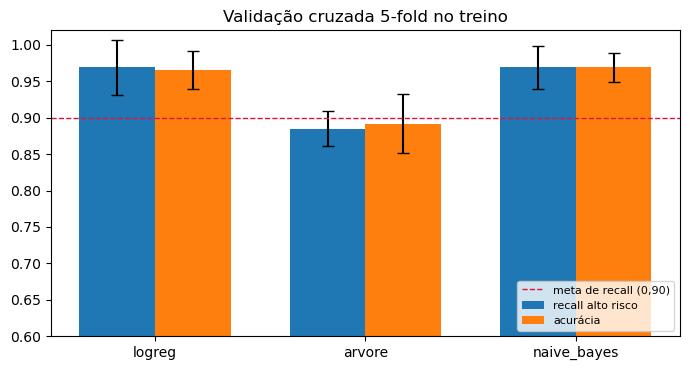

In [7]:
fig, eixo = plt.subplots(figsize=(7, 3.8))
posicoes = np.arange(len(cv))
eixo.bar(posicoes - 0.18, cv["recall alto risco (média)"], 0.36, yerr=cv["recall (desvio)"], capsize=4, label="recall alto risco")
eixo.bar(posicoes + 0.18, cv["acurácia (média)"], 0.36, yerr=cv["acurácia (desvio)"], capsize=4, label="acurácia")
eixo.axhline(0.90, color="crimson", linestyle="--", linewidth=1, label="meta de recall (0,90)")
eixo.set_xticks(posicoes, cv.index)
eixo.set_ylim(0.6, 1.02)
eixo.set_title("Validação cruzada 5-fold no treino")
eixo.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

> A validação cruzada tende a ser **otimista**: dois terços do treino são templates, frases regulares que se parecem entre si. O teste, só com frases manuais, é a medida honesta.

## 4. Avaliação final no teste congelado

O teste é usado **uma única vez**, com o modelo já escolhido.

In [8]:
metricas = relatorio["teste"]
metas = relatorio["metas"]
pd.DataFrame([
    {"métrica": "recall alto risco", "teste": metricas["recall_alto_risco"], "meta": metas["recall_alto_risco"]},
    {"métrica": "acurácia", "teste": metricas["acuracia"], "meta": metas["acuracia"]},
    {"métrica": "precisão alto risco", "teste": metricas["precisao_alto_risco"], "meta": None},
    {"métrica": "F1 alto risco", "teste": metricas["f1_alto_risco"], "meta": None},
]).round(3).assign(cumpre=lambda t: np.where(t["meta"].isna(), "—", np.where(t["teste"] >= t["meta"], "sim", "NÃO")))

,métrica,teste,meta,cumpre
0,recall alto risco,0.900,0.9,sim
1,acurácia,0.917,0.8,sim
2,precisão alto risco,0.931,NaN,—
3,F1 alto risco,0.915,NaN,—


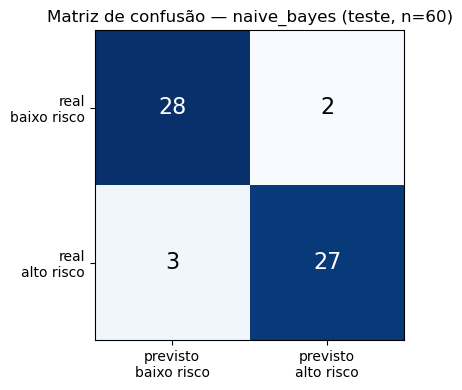

Violações das metas: nenhuma


In [9]:
matriz = np.array(metricas["matriz_confusao"]["valores"])
rotulos = metricas["matriz_confusao"]["rotulos"]

fig, eixo = plt.subplots(figsize=(4.6, 4))
eixo.imshow(matriz, cmap="Blues")
for i in range(2):
    for j in range(2):
        eixo.text(j, i, matriz[i, j], ha="center", va="center", fontsize=16,
                  color="white" if matriz[i, j] > matriz.max() / 2 else "black")
eixo.set_xticks([0, 1], [f"previsto\n{r}" for r in rotulos])
eixo.set_yticks([0, 1], [f"real\n{r}" for r in rotulos])
eixo.set_title(f"Matriz de confusão — {relatorio['modelo_escolhido']} (teste, n={metricas['n']})")
plt.tight_layout()
plt.show()

print("Violações das metas:", relatorio["violacoes"] or "nenhuma")

**Leitura:** as metas foram cumpridas, mas o recall ficou **exatamente** em 0,90: 3 dos 30 casos de alto risco foram classificados como baixo risco. Não há folga. Qualquer mudança futura precisa ser medida com cuidado, e o próximo passo natural é um segundo conjunto de teste cego, escrito pela equipe.

## 5. Transparência: todos os modelos e as regras no teste

Esta tabela **não** foi usada para escolher o modelo. Ela mostra como os outros candidatos e a linha de base por regras (o extrator da Parte 1 aplicando os critérios A1–A4) se sairiam.

In [10]:
linhas = []
for nome, modelo in criar_modelos().items():
    modelo.fit(treino["frase"], treino["situacao"])
    m = calcular_metricas(teste["situacao"].tolist(), modelo.predict(teste["frase"]).tolist())
    linhas.append({"modelo": nome, "escolhido": nome == relatorio["modelo_escolhido"], **{k: m[k] for k in ("acuracia", "recall_alto_risco", "precisao_alto_risco")}})

previsto_regras = [classificar_por_regras(f, base)[0] for f in teste["frase"]]
m = calcular_metricas(teste["situacao"].tolist(), previsto_regras)
linhas.append({"modelo": "regras (Parte 1)", "escolhido": False, **{k: m[k] for k in ("acuracia", "recall_alto_risco", "precisao_alto_risco")}})
pd.DataFrame(linhas).round(3)

,modelo,escolhido,acuracia,recall_alto_risco,precisao_alto_risco
0,logreg,False,0.933,0.967,0.906
1,arvore,False,0.833,0.833,0.833
2,naive_bayes,True,0.917,0.900,0.931
3,regras (Parte 1),False,0.717,0.433,1.000


Duas leituras:

- **A regressão logística teria ido melhor no teste** (recall 0,967 contra 0,900). Na validação cruzada, ela e o Naive Bayes **empataram no recall** (0,969), e o desempate pela acurácia favoreceu o Naive Bayes (0,969 contra 0,965). Trocar de modelo agora seria escolher olhando o teste, e o resultado deixaria de ser uma estimativa honesta. A troca fica como hipótese para a próxima rodada, a ser confirmada num teste novo.
- **As regras** acertam quando o paciente usa o vocabulário da base, mas o recall cai muito com linguagem livre ("queimação no peito", "apaguei", "peito apertado"). É o **viés de vocabulário de livro**, analisado no notebook 03. O ML generaliza melhor porque aprendeu com frases variadas.

## 6. O que o modelo aprendeu

Para o Naive Bayes, a influência de um termo é a diferença entre o log da probabilidade dele em `alto risco` e em `baixo risco`. Valores positivos empurram para alto risco.

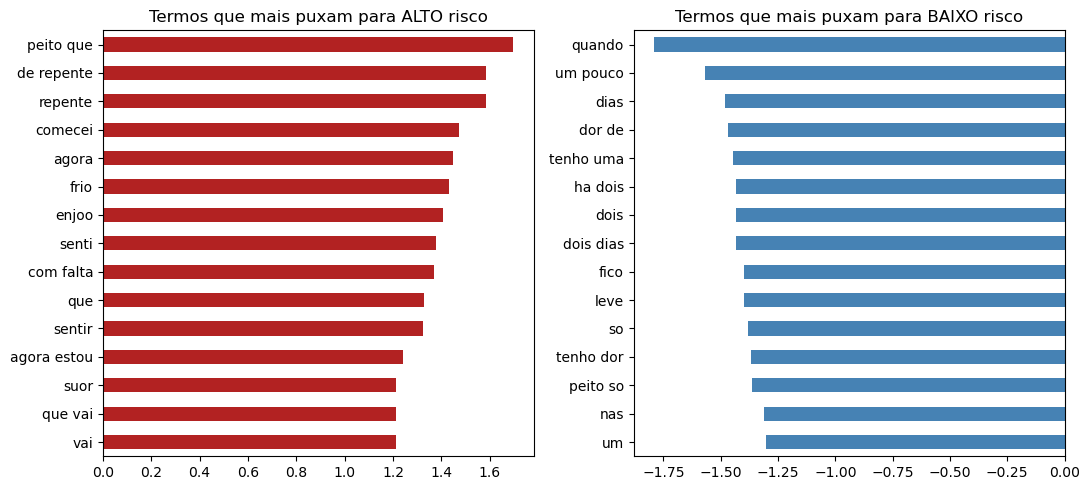

In [11]:
escolhido = criar_modelos()[relatorio["modelo_escolhido"]].fit(treino["frase"], treino["situacao"])
termos = escolhido.named_steps["tfidf"].get_feature_names_out()
classificador = escolhido.named_steps["clf"]

if hasattr(classificador, "feature_log_prob_"):
    indice = {c: i for i, c in enumerate(classificador.classes_)}
    influencia = classificador.feature_log_prob_[indice[POSITIVO]] - classificador.feature_log_prob_[indice[NEGATIVO]]
else:
    influencia = classificador.coef_[0] if classificador.classes_[1] == POSITIVO else -classificador.coef_[0]
influencia = pd.Series(influencia, index=termos).sort_values()

fig, eixos = plt.subplots(1, 2, figsize=(11, 5))
influencia.tail(15).plot.barh(ax=eixos[0], color="firebrick", title="Termos que mais puxam para ALTO risco")
influencia.head(15).iloc[::-1].plot.barh(ax=eixos[1], color="steelblue", title="Termos que mais puxam para BAIXO risco")
plt.tight_layout()
plt.show()

**Nem todo termo influente é clínico.**

- **Do lado do alto risco:** há termos com sentido clínico ("de repente", "frio", "enjoo", "suor", "com falta"), mas também palavras de **molde** dos templates ("comecei", "agora", "agora estou", "senti", "que", "vai"). Elas vêm de aberturas como "Comecei a sentir…" e de sinais como "…que vai para o braço".
- **Do lado do baixo risco** dominam palavras que **não são sintoma**: "quando", "um pouco", "há dois dias", "tenho uma", "só". O "há dois dias" vem dos templates de queixa não cardíaca, e o "só" dos templates de negação ("…, só sinto um cansaço leve").

São **pistas espúrias** herdadas do jeito de gerar os dados: o modelo aprendeu um pouco do "estilo" de cada classe, não só a clínica. O notebook 03 (seção 5) mede isso.

## 7. Análise de erros

In [12]:
prob_alto = escolhido.predict_proba(teste["frase"])[:, list(escolhido.classes_).index(POSITIVO)]
previsto = escolhido.predict(teste["frase"])

erros = teste.assign(previsto=previsto, prob_alto=prob_alto.round(2), regras=previsto_regras)
erros = erros[erros["previsto"] != erros["situacao"]]
erros[["criterio", "frase", "situacao", "previsto", "prob_alto", "regras"]]

,criterio,frase,situacao,previsto,prob_alto,regras
4,A2,Desmaiei no banheiro hoje de manhã e só acordei com minha filha me chamando.,alto risco,baixo risco,0.38,alto risco
23,A1,"Senti de repente uma dor fortíssima no peito e nas costas, como uma facada.",alto risco,baixo risco,0.42,baixo risco
27,A1,"Sinto dor no peito e falta de ar ao mesmo tempo, começou faz uma hora.",alto risco,baixo risco,0.47,alto risco
45,B2,Sinto o estômago estufado e arroto muito depois do almoço.,baixo risco,alto risco,0.55,baixo risco
49,B1,Estou mais cansado que o normal desde que comecei a dormir tarde.,baixo risco,alto risco,0.62,baixo risco


O peso de cada palavra no erro foi conferido termo a termo (influência × TF-IDF):

- **Falsos negativos (o erro grave):**
  - **"Desmaiei no banheiro hoje de manhã e só acordei…"** (síncope). "Desmaiei" quase não pesou (+0,11). Puxaram para baixo risco:
    - "só", dos templates de negação (−0,30);
    - "hoje de manhã", dos templates de queixa não cardíaca (até −0,25).
  - **"Sinto dor no peito e falta de ar ao mesmo tempo…"** é o exemplo de alto risco do próprio enunciado.
    - "Dor no peito" e "falta de ar" ficaram **quase neutros**: no treino, aparecem em 20 e 15 frases de alto risco, mas também em 15 e 19 de baixo risco.
    - Das 15 frases de baixo risco com "dor no peito", 13 são negações ("Não tenho dor no peito nem falta de ar, só…").
    - Das 19 com "falta de ar", 10 são negações e 9 descrevem falta de ar leve e estável.
    - Com o sintoma neutralizado, palavras sem sentido clínico decidiram: "tempo" (−0,28), "faz" (−0,19), "sinto dor" (−0,14).
    - As regras, que tratam negação, acertam.
  - **"Dor fortíssima no peito e nas costas, como uma facada"**: "fortíssima" e "facada" não existem no vocabulário do treino, e "nas costas" vem de queixas musculoesqueléticas (−0,38).
- **Falsos positivos:** "depois do almoço" (+0,36) e "comecei" (+0,36) são moldes de templates de alto risco.

As regras acertam 2 dos 3 falsos negativos. O notebook 03 mede essa complementaridade.

## 8. Recall por tipo de alarme

In [13]:
por_criterio = (
    teste.assign(acertou=previsto == teste["situacao"])
    .groupby("criterio")
    .agg(frases=("frase", "size"), acertos=("acertou", "sum"))
)
por_criterio["taxa"] = (por_criterio["acertos"] / por_criterio["frases"]).round(2)
por_criterio.insert(0, "significado", por_criterio.index.map(criterios))
por_criterio

,significado,frases,acertos,taxa
criterio,,,,
A1,dor torácica + sinal de alarme,17,15,0.88
A2,síncope,4,3,0.75
A3,dispneia em repouso/súbita/noturna,5,5,1.00
A4,equivalente atípico,4,4,1.00
B1,sintoma leve e estável,13,12,0.92
B2,queixa não cardíaca,13,12,0.92
B3,alarme negado,4,4,1.00


## 9. Testando frases novas

As duas primeiras são os exemplos do enunciado.

In [14]:
def classificar(frase):
    p = escolhido.predict_proba([frase])[0][list(escolhido.classes_).index(POSITIVO)]
    regras, motivos = classificar_por_regras(frase, base)
    return {
        "frase": frase,
        "modelo": POSITIVO if p >= 0.5 else NEGATIVO,
        "prob_alto": round(float(p), 2),
        "regras": regras,
        "motivo (regras)": "; ".join(motivos) or "—",
    }


pd.DataFrame([classificar(f) for f in [
    "sinto dor no peito e falta de ar",
    "tive um leve incômodo nas costas",
    "Estou com um aperto no peito que vai para o braço há meia hora.",
    "Não sinto dor no peito, só um cansaço leve no fim do dia.",
    "Desmaiei hoje cedo no ônibus.",
    "Estou com coriza e um pouco de dor de cabeça.",
]])

,frase,modelo,prob_alto,regras,motivo (regras)
0,sinto dor no peito e falta de ar,baixo risco,0.41,alto risco,A1: dor torácica com sinal de alarme
1,tive um leve incômodo nas costas,baixo risco,0.14,baixo risco,—
2,Estou com um aperto no peito que vai para o braço há meia hora.,alto risco,0.90,alto risco,A1: dor torácica com sinal de alarme
3,"Não sinto dor no peito, só um cansaço leve no fim do dia.",baixo risco,0.03,baixo risco,—
4,Desmaiei hoje cedo no ônibus.,alto risco,0.60,alto risco,A2: síncope
5,Estou com coriza e um pouco de dor de cabeça.,baixo risco,0.08,baixo risco,—


**Repare na primeira linha:** o exemplo de alto risco do enunciado sai como baixo risco no modelo, mas as regras acertam. Esse é o falso negativo da seção 7, que se repete fora do teste.

## 10. Conclusões

- O **Naive Bayes com TF-IDF**, escolhido só pela validação cruzada, cumpriu as metas no teste congelado: acurácia 0,917 e recall de alto risco 0,900 (precisão 0,931). O recall ficou no limite, sem folga.
- O modelo **generaliza melhor que as regras** em linguagem livre, mas herda dois problemas típicos do saco de palavras:
  - é cego à negação;
  - aprende pistas espúrias dos templates.
- As **regras da Parte 1** são explicáveis e tratam negação, mas dependem do vocabulário da base.
- Próximos passos (escolhidos por validação cruzada, nunca pelo teste):
  - combinar ML e regras como rede de segurança (notebook 03, seção 7);
  - reconsiderar o critério de desempate entre modelos;
  - trocar parte dos templates por frases manuais variadas;
  - ter um segundo teste cego escrito pela equipe;
  - validar o critério de rótulo com a Dra. Fernanda.

---

> ⚠️ **AVISO CLÍNICO:** Este sistema é um protótipo acadêmico e **NÃO** substitui avaliação médica.  
> Supervisionado por Dra. Fernanda Fassina (CRM-SP 169944).